In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import seaborn as sns

In [5]:
!git clone https://github.com/varaiitj2527/PRMLProject.git
%cd PRMLProject

Cloning into 'PRMLProject'...
remote: Enumerating objects: 156, done.
remote: Counting objects: 100% (138/138), done.
remote: Compressing objects: 100% (120/120), done.
remote: Total 156 (delta 50), reused 29 (delta 5), pack-reused 18 (from 2)
Receiving objects: 100% (156/156), 209.83 MiB | 24.16 MiB/s, done.
Resolving deltas: 100% (50/50), done.
Updating files: 100% (46/46), done.
Filtering content: 100% (14/14), 1.29 GiB | 52.79 MiB/s, done.
Encountered 2 file(s) that should have been pointers, but weren't:
	PreProcessedData/quicknet_test.pkl
	PreProcessedData/quicknet_train.pkl
/content/PRMLProject/PRMLProject


In [6]:
def unpickle(file):
    with open(file, 'rb') as f:
        return pickle.load(f)

In [7]:
X_train_knn_hog_pca=unpickle("PreProcessedData/TrainFeaturesHoG_PCA.pkl")
print(X_train_knn_hog_pca.shape)
y_train=unpickle("PreProcessedData/Labels_train.pkl")
print(y_train.shape)
X_test_knn_hog_pca=unpickle("PreProcessedData/TestFeaturesHoG_PCA.pkl")
y_test=unpickle("PreProcessedData/Labels_test.pkl")

(50000, 170)
(50000,)


Writing our own KNN Implementation

In [8]:
import numpy as np
from collections import Counter
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

def find_knn(k=10, X_train=X_train_knn_hog_pca, X_test=X_test_knn_hog_pca, y_train=y_train, y_test=y_test):
    results = []

    for idx, test_sample in enumerate(tqdm(X_test)):
        # Compute distances in a vectorized way
        distances = np.linalg.norm(X_train - test_sample, axis=1)

        # Get indices of k smallest distances
        k_nearest_indices = np.argsort(distances)[:k]

        # Get labels of k nearest neighbors
        k_labels = y_train[k_nearest_indices]

        # Majority vote for classification
        predicted_label = Counter(k_labels).most_common(1)[0][0]
        results.append(predicted_label)

    # Compute and print accuracy
    accuracy = accuracy_score(y_test, results)
    print(f"Accuracy: {accuracy * 100:.2f}%")

    # Compute and print confusion matrix
    conf_matrix = confusion_matrix(y_test, results)
    print("Confusion Matrix:\n", conf_matrix)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()


100%|██████████| 10000/10000 [10:26<00:00, 15.97it/s]


Accuracy: 53.00%
Confusion Matrix:
 [[497  27  70  11 122  11  74  24 148  16]
 [ 10 728   5   2  37   5  94   3  42  74]
 [ 32  13 358  25 218  70 229  20  21  14]
 [  7  24  43 126 276  99 330  35   9  51]
 [  7   8  29   9 664  13 215  31   7  17]
 [  1   6  37  55 215 276 328  50   9  23]
 [  4  10  18   6  67  24 854   3   8   6]
 [  1  12  30  19 217  54 116 512   6  33]
 [ 53  87  22   1  59   7  60  16 616  79]
 [  9  70  13  10  79  10  79  17  44 669]]


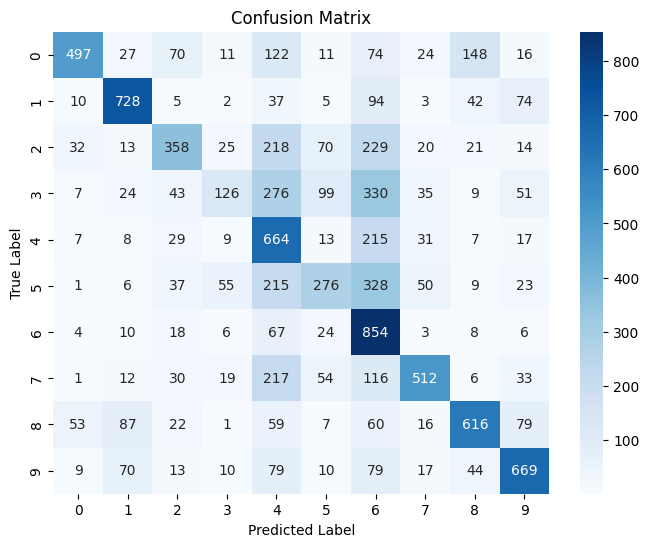

In [9]:
find_knn()

using SkLearn Library with Euclidean as the distance metric

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def find_knn1(k=10, X_train=X_train_knn_hog_pca, X_test=X_test_knn_hog_pca, y_train=y_train, y_test=y_test):
    # Initialize k-NN classifier
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')

    # Train the model
    knn.fit(X_train, y_train)

    # Predict on test data
    y_pred = knn.predict(X_test)

    # Compute and print accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy * 100:.2f}%")

    # Compute and print confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", conf_matrix)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()


Accuracy: 52.90%
Confusion Matrix:
 [[527  25  72  16 133  10  58  13 134  12]
 [ 14 751   5   3  40   4  90   3  34  56]
 [ 37  16 387  27 218  62 213  15  17   8]
 [  8  28  61 147 286  99 298  25   7  41]
 [ 13   9  46  20 670  11 188  23   5  15]
 [  1  11  62  68 244 260 288  46   4  16]
 [  5  11  25  10  80  24 831   2   6   6]
 [  5  14  43  23 236  51 110 489   5  24]
 [ 63  95  27   6  72   4  57  10 604  62]
 [ 11  81  15  17  97   9  86  18  42 624]]


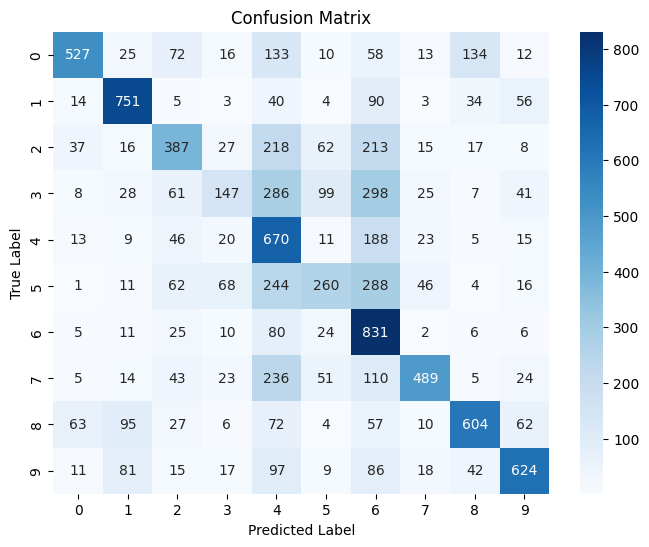

In [ ]:
find_knn1()

using SkLearn Library with manhattan as the distance metric

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def find_knn2(k=10, X_train=X_train_knn_hog_pca, X_test=X_test_knn_hog_pca, y_train=y_train, y_test=y_test):
    # Initialize k-NN classifier with Manhattan distance
    knn = KNeighborsClassifier(n_neighbors=k, metric='manhattan')

    # Train the model
    knn.fit(X_train, y_train)

    # Predict on test data
    y_pred = knn.predict(X_test)

    # Compute and print accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy * 100:.2f}%")

    # Compute and print confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", conf_matrix)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()


Accuracy: 49.32%
Confusion Matrix:
 [[511  27  60   6 159   8  86  21 107  15]
 [ 17 709   5   3  51   1 112   2  37  63]
 [ 37  16 328  20 261  58 245  16  15   4]
 [ 13  20  58 127 304  86 346  19   5  22]
 [ 19   5  47  16 657   9 222  17   3   5]
 [  3   6  56  61 268 227 323  34   6  16]
 [  7   9  17   8  96  16 838   1   7   1]
 [  9  16  45  31 263  33 161 425   2  15]
 [ 76  96  27   6 107   5  68  13 541  61]
 [ 17  73  22   6 134  10 115  21  33 569]]


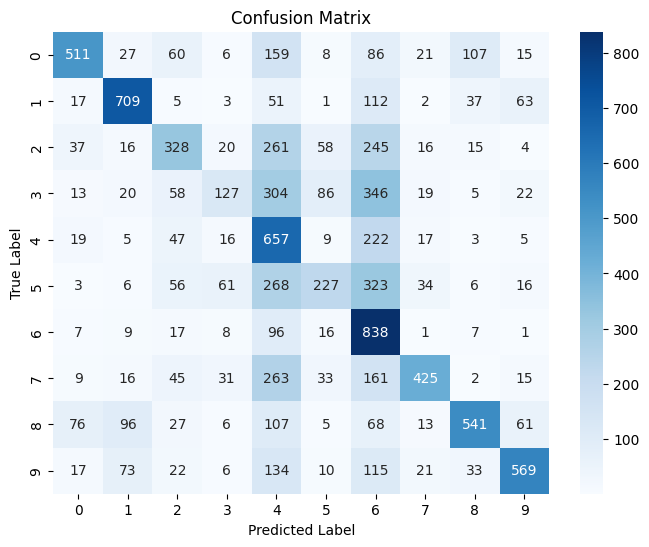

In [ ]:
find_knn2()

using SkLearn Library with Canberra as the distance metric

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def find_knn3(k=10, X_train=X_train_knn_hog_pca, X_test=X_test_knn_hog_pca, y_train=y_train, y_test=y_test):
    # Initialize k-NN classifier with Canberra distance
    knn = KNeighborsClassifier(n_neighbors=k, metric='canberra')

    # Train the model
    knn.fit(X_train, y_train)

    # Predict on test data
    y_pred = knn.predict(X_test)

    # Compute and print accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy * 100:.2f}%")

    # Compute and print confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", conf_matrix)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix - Canberra Distance")
    plt.show()




Accuracy: 43.33%
Confusion Matrix:
 [[606  67  73  23  32  23  27  22 102  25]
 [ 46 687  29  31  24  16  34  17  67  49]
 [113  57 380 106  82  98  77  37  36  14]
 [ 76  82 125 294  97 118 102  56  17  33]
 [ 87  70 130 104 321  74  93  57  31  33]
 [ 52  57 152 189  96 267  89  61   8  29]
 [ 46  83  91  90  87  63 467  34  16  23]
 [ 48  63  83 113  96  77  38 432  20  30]
 [197 138  45  23  20  15  19  19 480  44]
 [ 66 164  46  55  59  45  44  45  77 399]]


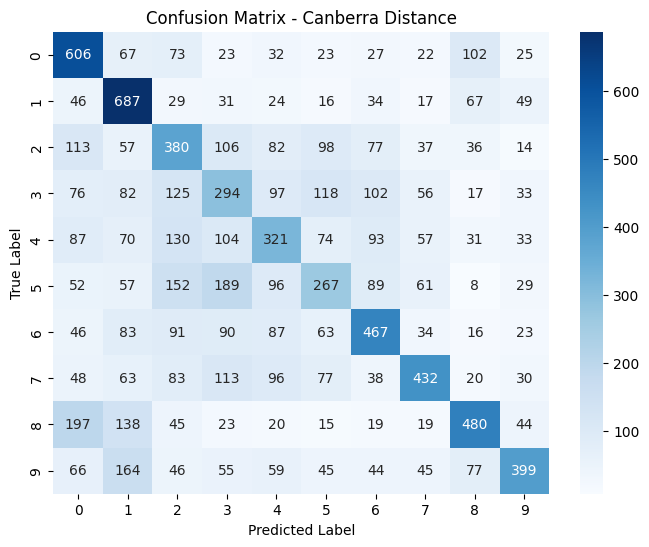

In [ ]:
find_knn3()

using SkLearn Library with Bray Curtis as the distance metric

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def find_knn4(k=10, X_train=X_train_knn_hog_pca, X_test=X_test_knn_hog_pca, y_train=y_train, y_test=y_test):
    # Initialize k-NN classifier with Bray-Curtis distance
    knn = KNeighborsClassifier(n_neighbors=k, metric='braycurtis')

    # Train the model
    knn.fit(X_train, y_train)

    # Predict on test data
    y_pred = knn.predict(X_test)

    # Compute and print accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy * 100:.2f}%")

    # Compute and print confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", conf_matrix)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix - Bray-Curtis Distance")
    plt.show()


Accuracy: 59.04%
Confusion Matrix:
 [[722  36  61  23  25  11   8   7 100   7]
 [ 32 837  11   4   7   4   9   4  56  36]
 [ 90  28 546  65  75  64  68  25  31   8]
 [ 56  58 124 350  78 154  87  47  18  28]
 [ 59  38 110  94 453  54  85  69  20  18]
 [ 27  27 125 185  70 393  75  72  10  16]
 [ 24  41  74  62  47  64 653   9  23   3]
 [ 20  22  72  57  68  57  18 660  13  13]
 [126  84  21  11  13   8  11   7 692  27]
 [ 43 144  20  37  18  24  17  30  69 598]]


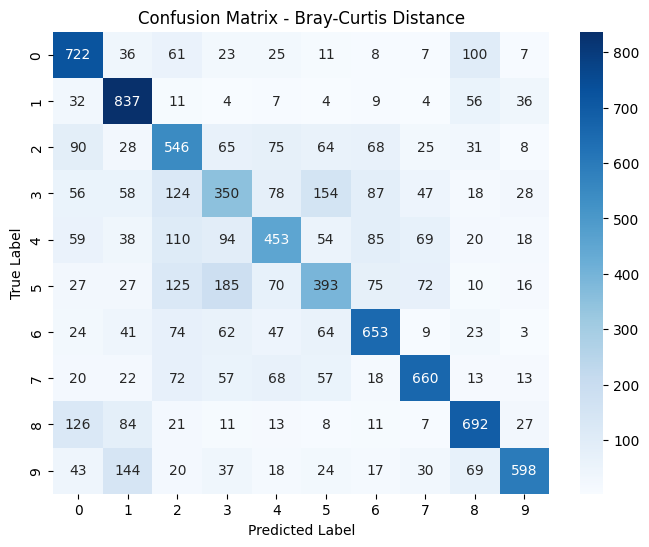

In [ ]:
find_knn4()